In [2]:
!pip install torch torchvision matplotlib numpy diffusers transformers accelerate safetensors

^C



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


# MNIST

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 10.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 338kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.13MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.55MB/s]


In [5]:
dataloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

# Clase Generador

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super(Generator, self).__init__()
        
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            
            nn.Linear(1024, 28*28),
            nn.Tanh()
        )
        
    def forward(self, z):
        img = self.model(z)
        img = img.view(z.size(0), 1, 28, 28)
        return img

# Clase Discriminador

In [7]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        self.model = nn.Sequential(
            nn.Flatten(),
            
            nn.Linear(28*28, 512),
            nn.LeakyReLU(0.2),
            
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
        
    def forward(self, img):
        validity = self.model(img)
        return validity

# Instancias

In [8]:
latent_dim = 100

generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

In [9]:
criterion = nn.BCELoss()

optimizer_G = optim.Adam(generator.parameters(), lr = 0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr = 0.0002)

In [11]:
epochs = 1

for epoch in range(epochs):
    for i, (imgs, _) in enumerate(dataloader):
        
        real_imgs = imgs.to(device)
        batch_size = real_imgs.size(0)
        
        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)
        
        # Entrenar el Discriminador
        optimizer_D.zero_grad()
        
        real_output = discriminator(real_imgs)
        d_loss_real = criterion(real_output, real_labels)
        
        z = torch.randn(batch_size, latent_dim).to(device)
        
        fake_imgs = generator(z)
        
        fake_output = discriminator(fake_imgs.detach())
        d_loss_fake = criterion(fake_output, fake_labels)
        
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()
        
        
        # Entrenar el Generador
        optimizer_G.zero_grad()
        
        z = torch.randn(batch_size, latent_dim).to(device)
        generated_imgs = generator(z)
        
        output = discriminator(generated_imgs)
        g_loss = criterion(output, real_labels)
        
        g_loss.backward()
        optimizer_G.step()
        
        print(f"Epoch [{epoch+1}/{epochs}] Batch {i+1}/{len(dataloader)} \
              Loss D: {d_loss.item():.4f}, Loss G: {g_loss.item():.4f}")
        
        

Epoch [1/1] Batch 1/469               Loss D: 0.0007, Loss G: 8.4145
Epoch [1/1] Batch 2/469               Loss D: 0.0006, Loss G: 8.4306
Epoch [1/1] Batch 3/469               Loss D: 0.0006, Loss G: 8.4468
Epoch [1/1] Batch 4/469               Loss D: 0.0005, Loss G: 8.4616
Epoch [1/1] Batch 5/469               Loss D: 0.0005, Loss G: 8.4755
Epoch [1/1] Batch 6/469               Loss D: 0.0005, Loss G: 8.4846
Epoch [1/1] Batch 7/469               Loss D: 0.0005, Loss G: 8.4933
Epoch [1/1] Batch 8/469               Loss D: 0.0004, Loss G: 8.5126
Epoch [1/1] Batch 9/469               Loss D: 0.0005, Loss G: 8.5288
Epoch [1/1] Batch 10/469               Loss D: 0.0005, Loss G: 8.5453
Epoch [1/1] Batch 11/469               Loss D: 0.0005, Loss G: 8.5588
Epoch [1/1] Batch 12/469               Loss D: 0.0005, Loss G: 8.5758
Epoch [1/1] Batch 13/469               Loss D: 0.0005, Loss G: 8.5882
Epoch [1/1] Batch 14/469               Loss D: 0.0005, Loss G: 8.5915
Epoch [1/1] Batch 15/469     

# Visualizar las imágenes

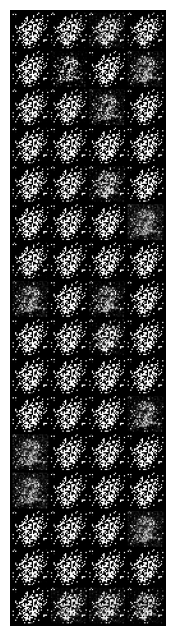

In [12]:
z = torch.randn(64, latent_dim).to(device)
generated_imgs = generator(z).detach().cpu()

grid = vutils.make_grid(generated_imgs, nrow=4, normalize=True)

plt.figure(figsize=(8,8))
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.axis("off")
plt.show()

# Difusión

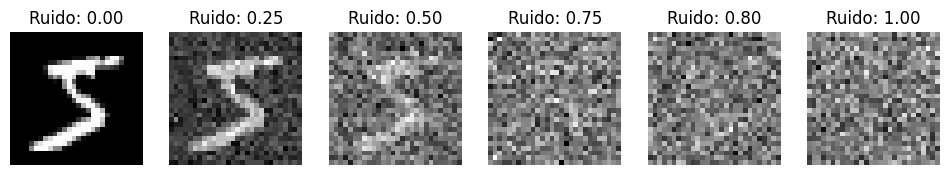

In [13]:
# Simular adición progresiva de ruido a las imágenes reales y observar cómo el Discriminador se adapta a esta nueva tarea.

sample_imgs, _ = dataloader.dataset[0]

sample_imgs = sample_imgs.unsqueeze(0).to(device)

def add_noise(img, noise_level):
    noise = torch.randn_like(img)
    noise_img = (1 - noise_level) * img + noise_level * noise
    return noise_img

noise_levels = [0.0, 0.25, 0.5, 0.75, 0.8, 1.0]

plt.figure(figsize=(12, 6))

for i, noise_level in enumerate(noise_levels):
    noise_img = add_noise(sample_imgs, noise_level)
    
    plt.subplot(1, len(noise_levels), i+1)
    plt.imshow(noise_img.squeeze().cpu(), cmap='gray')
    plt.title(f"Ruido: {noise_level:.2f}")
    plt.axis('off')
    
plt.show()

# Difusión estable

In [2]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "CompVis/stable-diffusion-v1-4"

pipe = StableDiffusionPipeline.from_pretrained(model_id)

pipe.to("cpu")

prompt = "A futuristic classroom where students learn artificial intelligence, digital art style, detailed, cinematic lighting."

image = pipe(
    prompt = prompt,
    num_inference_steps = 30,
    guidance_scale = 7.5,
).images[0]

image.save("generated_image.png")

image.show()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

: 

In [ ]:
# Prompt negativo

negative_prompt = "A clean educational infographic about generative AI, modern design, high quality."

image = pipe(
    prompt = prompt,
    num_inference_steps = 30,
    guidance_scale = 7.5,
).images[0]

image.save("generated_image_negative.png")

image.show()